In [5]:
import geopandas as gpd
import rasterio as rio
import re
from sklearn.preprocessing import OrdinalEncoder
## Import libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature

### Import the created function
from src.utils import merge_metadata_data

In [16]:
path = '/mnt/d/desktop/Dados-Geo-Espaciais/Franca/sylvioecoregion/ser_l93.shp'
ecogdf = gpd.read_file(path)

## Create a new column
ecogdf['GRECO'] = ecogdf['codeser'].apply(lambda x:re.findall(r'^(.+?)\d+$', x))
ecogdf['GRECO'] = ecogdf['GRECO'].apply(lambda x:x[0])

## Drop inconsistent values
ecogdf.drop(index=ecogdf.loc[ecogdf['codeser']=='-1'].index, axis=0, inplace=True)

## Convert to 4326 ## Match plant species
## Aggregate into the zones
ecogdf_4326 = ecogdf.to_crs("EPSG:4326").dissolve(by='GRECO')

In [17]:
ecogdf_4326.columns

Index(['geometry', 'codeser', 'NomSER'], dtype='object')

<Axes: >

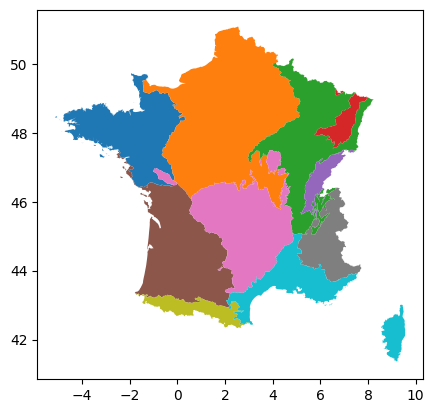

In [47]:
ecogdf_4326.plot(column=ecogdf_4326.index)

### Open X train data

In [2]:
path_metadata = "/mnt/d/desktop/COPERNICUS/Classes/3-semester/ml/species/output/train_metadata.parquet"
path_data = "/mnt/d/desktop/COPERNICUS/Classes/3-semester/ml/species/output/train_join.parquet"
test_path = ""
test_metadata_path = "/mnt/d/Desktop/Copernicus/classes/3-semester/ml/species/output/test_metadata.parquet"

In [6]:

## Create the whole df
df = merge_metadata_data(path_metadata,path_data)

## drop non necessary columns 
df = df.drop(columns = ['year', 'geoUncertaintyInM', 'areaInM2','region', 'country'])
df.set_index("surveyId",inplace=True)
## Drop non feature columns but preserve the df to map easily
## since the order to the X index is the same order of the df.
columns_to_drop = ['lon', 'lat', 'speciesId','predict']

X = df.drop(columns=columns_to_drop)

In [ ]:
## Create the Geodf
dff = df.reset_index()[['surveyId','lon','lat','speciesId']]
gdf = gpd.GeoDataFrame(dff,
                        geometry = gpd.points_from_xy(dff["lon"],
                                                     dff["lat"]),
                        crs="EPSG:4326"
)

Perform a spatial Interpolation over the GRECO zones

In [23]:
## spatial interpolation

print(f"Shape of the gdf {gdf.shape}")
print(f"Shape of the ecoregions: {ecogdf_4326.shape}")
join = gpd.sjoin(left_df = ecogdf_4326,
                right_df = gdf,
                how='right',
                predicate='intersects')
print(f"Shape of the join operation: {join.shape }")

Shape of the gdf (13501, 5)
Shape of the ecoregions: (11, 3)
Shape of the join operation: (13501, 8)


In [24]:
join.head()

,GRECO,codeser,NomSER,surveyId,lon,lat,speciesId,geometry
0,F,F11,Terres rouges,333,-0.51736,45.80643,2474.0,POINT (-0.51736 45.80643)
1,C,C11,Ardenne primaire,410,5.61448,47.21759,2474.0,POINT (5.61448 47.21759)
2,B,B10,Côtes et plateaux de la Manche,779,1.70039,47.64019,2474.0,POINT (1.70039 47.64019)
3,B,B10,Côtes et plateaux de la Manche,1218,2.71272,47.76724,2474.0,POINT (2.71272 47.76724)
4,J,J10,Garrigues,2015,4.37398,44.47449,2474.0,POINT (4.37398 44.47449)


### Join with the Data of the DataFrame

In [27]:
df.head()

,lon,lat,speciesId,average_Bio1,average_Bio2,average_Bio3,average_Bio4,average_Bio5,average_Bio6,average_Bio7,...,soilgrids_Soilgrid-bdod,soilgrids_Soilgrid-cec,soilgrids_Soilgrid-cfvo,soilgrids_Soilgrid-clay,soilgrids_Soilgrid-nitrogen,soilgrids_Soilgrid-phh2o,soilgrids_Soilgrid-sand,soilgrids_Soilgrid-silt,soilgrids_Soilgrid-soc,predict
surveyId,,,,,,,,,,,,,,,,,,,,,
333,-0.51736,45.80643,2474.0,2858,81,3,5285,2982,2758,224,...,138.0,233.0,176.0,328.0,250.0,71.0,231.0,439.0,257.0,1
410,5.61448,47.21759,2474.0,2845,82,3,6304,2980,2727,253,...,131.0,194.0,128.0,291.0,249.0,56.0,146.0,562.0,338.0,1
779,1.70039,47.64019,2474.0,2849,79,3,5698,2977,2746,231,...,133.0,181.0,98.0,181.0,139.0,56.0,524.0,293.0,238.0,1
1218,2.71272,47.76724,2474.0,2845,76,3,5742,2972,2741,231,...,135.0,151.0,117.0,232.0,152.0,56.0,422.0,344.0,232.0,1
2015,4.37398,44.47449,2474.0,2868,89,3,6434,3017,2745,272,...,134.0,207.0,141.0,240.0,205.0,71.0,316.0,443.0,227.0,1


In [28]:
print(df.shape)
print(join.shape)
concat = pd.concat([df,
                    join.set_index('surveyId')[['GRECO','codeser']]
                    ],
                   axis=1)
print(concat.shape)

(13501, 50)
(13501, 8)
(13501, 52)


In [30]:
outpath = '/mnt/d/desktop/Copernicus/classes/3-semester/ml/species/output/ecoregions/train_join.parquet'
concat.reset_index().to_parquet(outpath,
                                engine='fastparquet')

### Plot to see the result

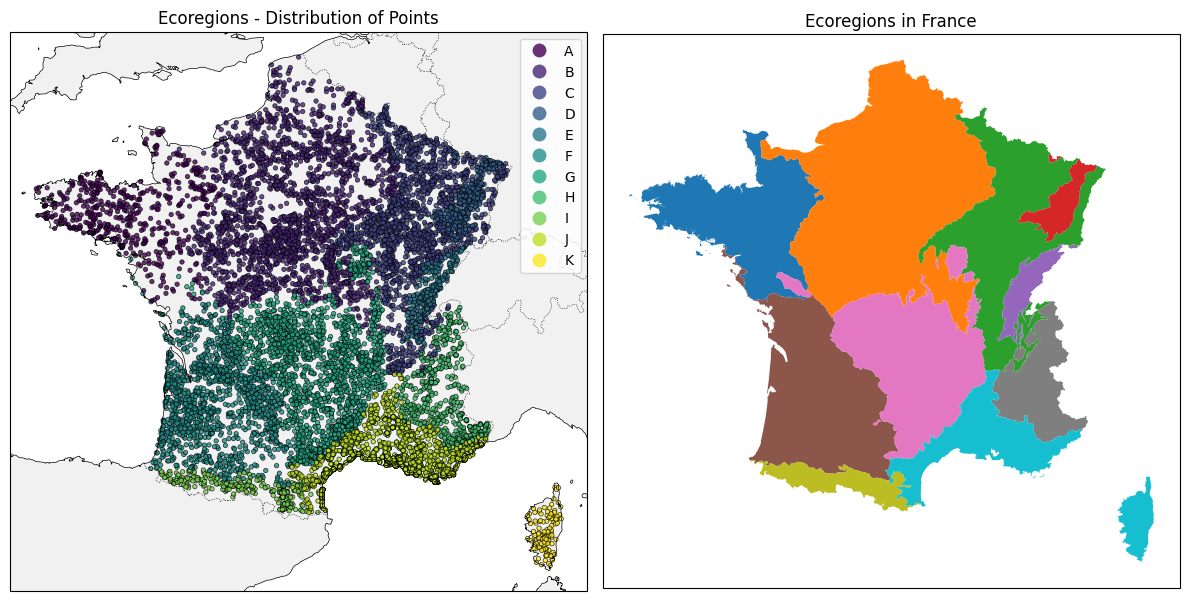

In [37]:
gdf_concat = gpd.GeoDataFrame(concat,
                                geometry = gpd.points_from_xy(concat["lon"],
                                                                concat["lat"]),
                                crs="EPSG:4326"
)
 
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,12),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax[0].add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax[0].add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax[0].add_feature(cfeature.COASTLINE, linewidth=0.5) 

gdf_concat.plot(
    column='GRECO',
    cmap='viridis',
    legend=True,
    ax=ax[0],
    markersize=10,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8
)
ax[0].set_title("Ecoregions - Distribution of Points")

ecogdf_4326.plot(column=ecogdf_4326.index,
                 ax= ax[1],
                 legend=False)
ax[1].set_title("Ecoregions in France")

plt.tight_layout()

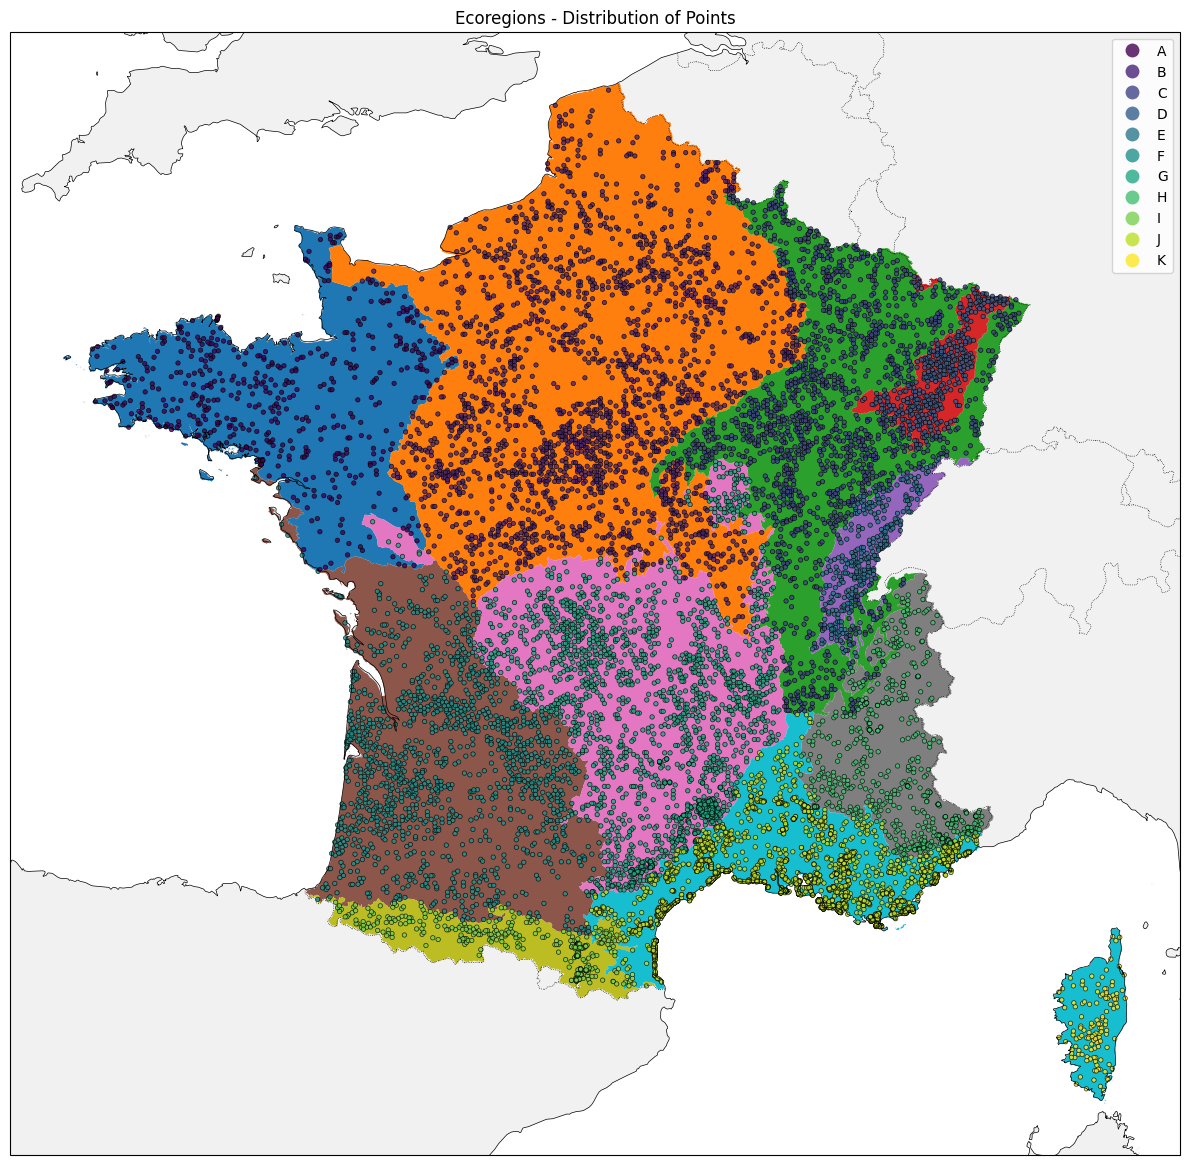

In [42]:
gdf_concat = gpd.GeoDataFrame(concat,
                                geometry = gpd.points_from_xy(concat["lon"],
                                                                concat["lat"]),
                                crs="EPSG:4326"
)
 
fig, ax = plt.subplots(figsize=(12,12),
                       subplot_kw={'projection': ccrs.PlateCarree()})
ax.add_feature(cfeature.BORDERS, linewidth=0.5, linestyle=':')
ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5) 
ecogdf_4326.plot(column=ecogdf_4326.index,
                 ax= ax,
                 legend=False)

gdf_concat.plot(
    column='GRECO',
    cmap='viridis',
    legend=True,
    ax=ax,
    markersize=10,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.8
)
ax.set_title("Ecoregions - Distribution of Points")



plt.tight_layout()